# Hiperparametrizacion para Regresión

1. Preparación de datos
2. Hiperparametrización con validación cruzada
3. Comparación de modelos
4. Guardar el modelo

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [ ]:
#Cargamos librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Preparación de Datos


In [ ]:
#Cargamos los datos
data = pd.read_csv("DS_salaries.csv", sep=';')
data.head()

,antiguedad,nivel_experiencia,tipo_empleo,porcentaje_tiempo_remoto,cantidad_empleados,salario_en_usd
0,2,Junior,Full-time,0,mas_250,79833
1,2,Senior,Full-time,0,menos_50,260000
2,2,Senior,Full-time,50,50-250,109024
3,2,Junior,Full-time,0,menos_50,20000
4,2,Senior,Full-time,50,mas_250,150000


In [ ]:
data.head()

,antiguedad,nivel_experiencia,tipo_empleo,porcentaje_tiempo_remoto,cantidad_empleados,salario_en_usd
0,2,Junior,Full-time,0,mas_250,79833
1,2,Senior,Full-time,0,menos_50,260000
2,2,Senior,Full-time,50,50-250,109024
3,2,Junior,Full-time,0,menos_50,20000
4,2,Senior,Full-time,50,mas_250,150000


In [ ]:
#Conocemos los datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 597 entries, 0 to 596
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   antiguedad                597 non-null    int64 
 1   nivel_experiencia         597 non-null    object
 2   tipo_empleo               597 non-null    object
 3   porcentaje_tiempo_remoto  597 non-null    int64 
 4   cantidad_empleados        597 non-null    object
 5   salario_en_usd            597 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 28.1+ KB


In [ ]:
#Corrección tipo de datos


In [ ]:
#Descripción de variables numéricas
data.describe()

,antiguedad,porcentaje_tiempo_remoto,salario_en_usd
count,597.000000,597.000000,597.000000
mean,0.587940,70.686767,107168.855946
std,0.688634,40.797800,58555.516292
min,0.000000,0.000000,2859.000000
25%,0.000000,50.000000,62649.000000
50%,0.000000,100.000000,100000.000000
75%,1.000000,100.000000,148261.000000
max,2.000000,100.000000,276000.000000


<Axes: >

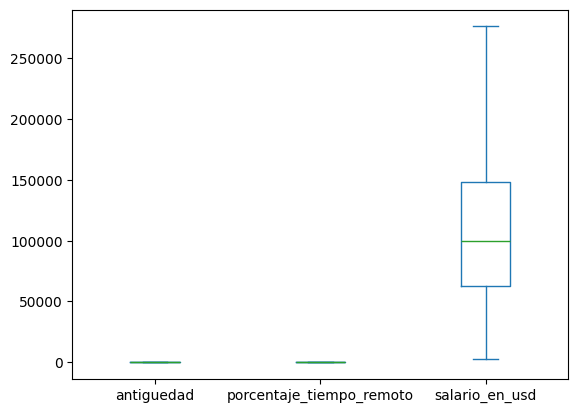

In [ ]:
data.plot(kind='box')

<Axes: xlabel='nivel_experiencia'>

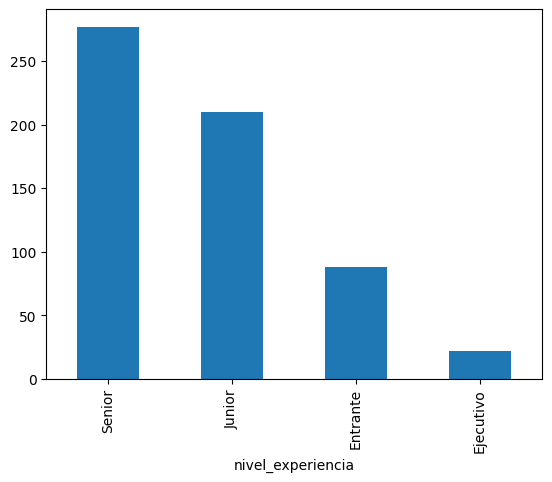

In [ ]:
#Descripción variables categóricas
data['nivel_experiencia'].value_counts().plot(kind='bar')

<Axes: xlabel='tipo_empleo'>

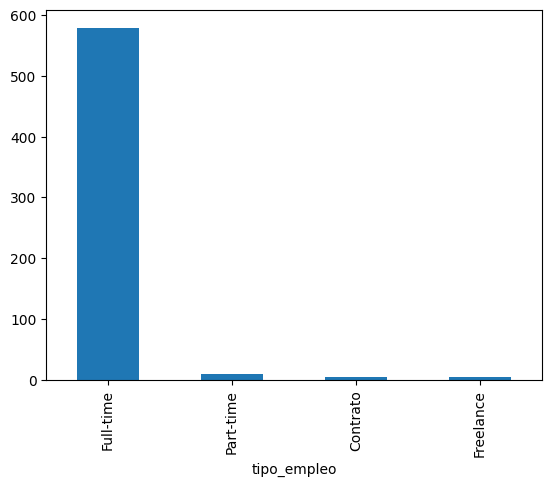

In [ ]:
data['tipo_empleo'].value_counts().plot(kind='bar')

<Axes: xlabel='cantidad_empleados'>

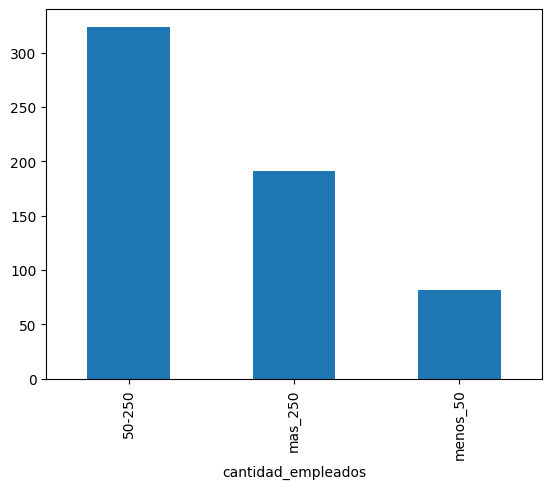

In [ ]:
data['cantidad_empleados'].value_counts().plot(kind='bar')

In [ ]:
#Sklearn sólo analiza variables numéricas
data = pd.get_dummies(data, columns=['nivel_experiencia','tipo_empleo','cantidad_empleados'], drop_first=False, dtype=int)
data.head()

,antiguedad,porcentaje_tiempo_remoto,salario_en_usd,nivel_experiencia_Ejecutivo,nivel_experiencia_Entrante,nivel_experiencia_Junior,nivel_experiencia_Senior,tipo_empleo_Contrato,tipo_empleo_Freelance,tipo_empleo_Full-time,tipo_empleo_Part-time,cantidad_empleados_50-250,cantidad_empleados_mas_250,cantidad_empleados_menos_50
0,2,0,79833,0,0,1,0,0,0,1,0,0,1,0
1,2,0,260000,0,0,0,1,0,0,1,0,0,0,1
2,2,50,109024,0,0,0,1,0,0,1,0,1,0,0
3,2,0,20000,0,0,1,0,0,0,1,0,0,0,1
4,2,50,150000,0,0,0,1,0,0,1,0,0,1,0


# **3. Hiperparametrización con validación cruzada**
https://scikit-learn.org/stable/modules/model_evaluation.html

In [ ]:
#Hiperparametrización
from sklearn.model_selection import GridSearchCV

scoring='neg_mean_absolute_percentage_error' #'neg_mean_absolute_error'
cv=10

#Dataframe para comparar modelos
medidas_CV= pd.DataFrame(index=['MAPE'])

In [ ]:
#Variables predictoras y objetivo
X = data.drop("salario_en_usd", axis = 1) # Variables predictoras
Y = data['salario_en_usd'] #Variable objetivo

# **Hiperparametrización Arbol de Regresión**

In [ ]:
#  Arbol
from sklearn.tree import DecisionTreeRegressor
modelTree = DecisionTreeRegressor()

# Definir los hiperparametros
criterion=['squared_error','absolute_error'] #Indice de información
min_samples_leaf=[2,10,50,100] # Cantidad de registros por hoja
max_depth=[10,20, 50] #Niveles de profundidad


param_grid = dict(criterion=criterion, min_samples_leaf=min_samples_leaf, max_depth=max_depth)
grid = GridSearchCV(estimator=modelTree, param_grid=param_grid, scoring=scoring, n_jobs=-1, cv=cv)
grid.fit(X, Y)

#Mejor modelo
modelTree= grid.best_estimator_
print( grid.best_params_)

#Dataframes de medidas
medidas_CV['Tree']=grid.best_score_
print(medidas_CV)

{'criterion': 'squared_error', 'max_depth': 50, 'min_samples_leaf': 2}
          Tree
MAPE -0.742933


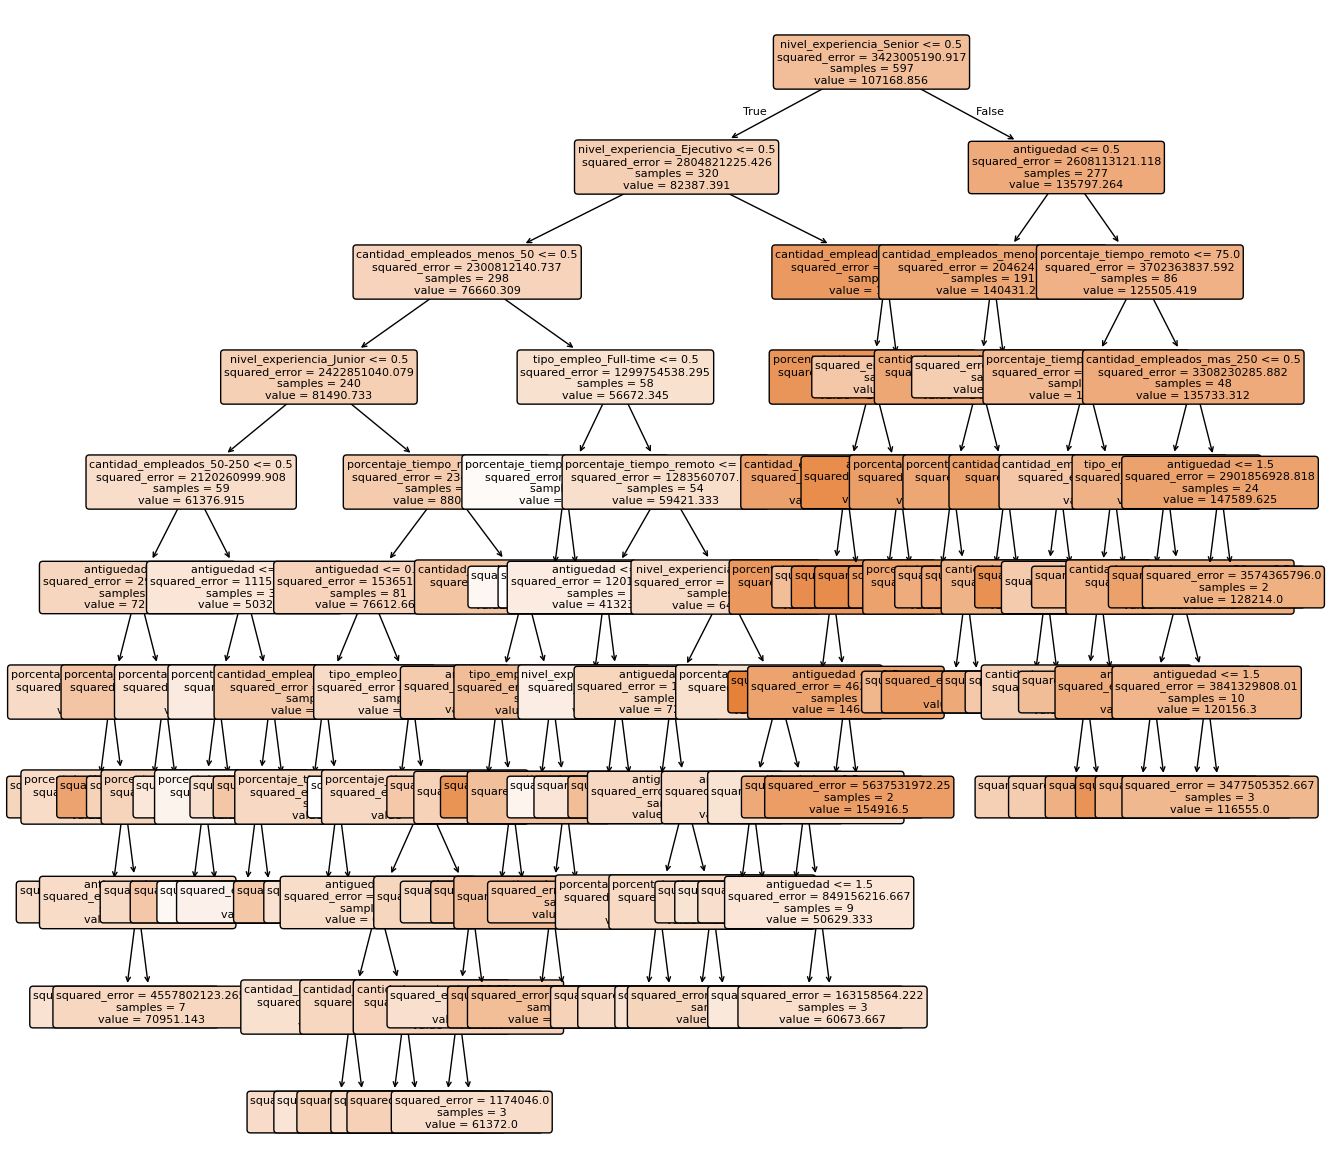

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,15))
plot_tree(modelTree, feature_names=X.columns.values, rounded=True, filled=True, fontsize=8)
plt.show()

# **Hiperparametrización Knn para Regresión**

In [ ]:
#Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
variables_norm=['antiguedad',	'porcentaje_tiempo_remoto']
min_max_scaler.fit(data[variables_norm]) #Ajuste de los parametros: max - min
X[variables_norm]= min_max_scaler.transform(X[variables_norm]) #70%
X.head()

,antiguedad,porcentaje_tiempo_remoto,nivel_experiencia_Ejecutivo,nivel_experiencia_Entrante,nivel_experiencia_Junior,nivel_experiencia_Senior,tipo_empleo_Contrato,tipo_empleo_Freelance,tipo_empleo_Full-time,tipo_empleo_Part-time,cantidad_empleados_50-250,cantidad_empleados_mas_250,cantidad_empleados_menos_50
0,1.0,0.0,0,0,1,0,0,0,1,0,0,1,0
1,1.0,0.0,0,0,0,1,0,0,1,0,0,0,1
2,1.0,0.5,0,0,0,1,0,0,1,0,1,0,0
3,1.0,0.0,0,0,1,0,0,0,1,0,0,0,1
4,1.0,0.5,0,0,0,1,0,0,1,0,0,1,0


In [ ]:
#KNN
from sklearn.neighbors  import KNeighborsRegressor
modelKnn = KNeighborsRegressor()

# Definir los hiperparametros
n_neighbors=[1,3,5,7,13,27]
metric=['euclidean','minkowski']

#Grid
param_grid = dict(n_neighbors=n_neighbors, metric=metric)
grid = GridSearchCV(estimator=modelKnn, param_grid=param_grid, scoring=scoring, n_jobs=-1,cv=cv)
grid.fit(X, Y)

#Mejor modelo
modelKnn= grid.best_estimator_

#Medida de evaluación del mejor modelo
medidas_CV['Knn']=grid.best_score_

# Mejores párametros
print( grid.best_params_)

print(medidas_CV)

{'metric': 'euclidean', 'n_neighbors': 7}
          Tree       Knn
MAPE -0.742933 -0.760705


# **Hiperparametrización Red Neuronal para Regresión**

In [ ]:
#Red Neuronal

from sklearn.neural_network import MLPRegressor
modelNN = MLPRegressor()


# Definir los parametros
random_state=[1] #Semilla para generar número pseudoaleatorios
solver=['sgd'] # Regla de aprendizaje ['adam','sgd','lbfgs']
learning_rate=['constant'] #tasa de aprendizaje 'adaptive'
learning_rate_init=[0.2, 1.0, 1.5] #valor tasa de aprendizaje 0-2
momentum=[0.3, 0.5] #momentum 0-1
activation=['logistic', 'relu'] #'identity’, ‘logistic’, ‘tanh’, ‘relu’
hidden_layer_sizes=[4, 20,[8, 20]] # neuronas de la capa oculta ((input+output)/2)
max_iter = [10, 50,100] #iteraciones

#Grid
param_grid = dict(random_state=random_state,solver=solver,activation=activation, hidden_layer_sizes=hidden_layer_sizes, max_iter=max_iter, learning_rate=learning_rate,
                  learning_rate_init=learning_rate_init, momentum=momentum)
grid = GridSearchCV(estimator=modelNN, param_grid=param_grid, scoring=scoring, n_jobs=-1, cv=cv)
grid.fit(X, Y)

#Mejor modelo
modelNN= grid.best_estimator_

#Medida de evaluación del mejor modelo
medidas_CV['NN']=grid.best_score_

# Mejores párametros
print( grid.best_params_)

print(medidas_CV)

{'activation': 'relu', 'hidden_layer_sizes': 20, 'learning_rate': 'constant', 'learning_rate_init': 0.2, 'max_iter': 10, 'momentum': 0.3, 'random_state': 1, 'solver': 'sgd'}
          Tree       Knn        NN
MAPE -0.742933 -0.760705 -0.836835


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


# **Hiperparametrización SVM para Regresión**

In [ ]:
#SVM
from sklearn.svm import SVR
modelSVM = SVR()

# Definir los hiperparametros
C=[1] #Margen blando
kernel=['poly', 'rbf'] #'linear', 'poly', 'rbf', 'sigmoid'
degree=[2,3]

#Grid
param_grid = dict(C=C, kernel=kernel,degree=degree)
grid = GridSearchCV(estimator=modelSVM, param_grid=param_grid, scoring=scoring, n_jobs=-1, cv=cv)
grid.fit(X, Y)

#Mejor modelo
modelSVM= grid.best_estimator_

#Medida de evaluación del mejor modelo
medidas_CV['SVM']=grid.best_score_

# Mejores párametros
print( grid.best_params_)

print(medidas_CV)

{'C': 1, 'degree': 3, 'kernel': 'poly'}
          Tree       Knn        NN       SVM
MAPE -0.742933 -0.760705 -0.836835 -1.089286


# **Hiperparametrización Ensambles - Bagging para Regresión**

In [ ]:
#Bagging
from sklearn.ensemble import BaggingRegressor
model_bag = BaggingRegressor()


# Definir los hiperparametros
base_knn= KNeighborsRegressor(n_neighbors=1, metric='euclidean')
base_nn= MLPRegressor(activation="logistic",hidden_layer_sizes=(10), learning_rate='adaptive',
                     learning_rate_init=0.2, momentum= 0.3, max_iter=500, verbose=False)

estimator=[base_knn, base_nn] #Métodos de Machine Learning
n_estimators=[10,50,100]
max_samples=[0.6,0.7,0.8]

#Grid
param_grid = dict(estimator=estimator, n_estimators=n_estimators,max_samples=max_samples)
grid = GridSearchCV(estimator=model_bag, param_grid=param_grid, scoring=scoring, n_jobs=-1, cv=cv)
grid.fit(X, Y)

#Mejor modelo
model_bag= grid.best_estimator_

#Medida de evaluación del mejor modelo
medidas_CV['Bagging']=grid.best_score_

# Mejores párametros
print( grid.best_params_)

print(medidas_CV)

{'estimator': KNeighborsRegressor(metric='euclidean', n_neighbors=1), 'max_samples': 0.8, 'n_estimators': 10}
          Tree       Knn        NN       SVM  Bagging
MAPE -0.742933 -0.760705 -0.836835 -1.089286 -0.75086


# **4. Comparación de Modelos**

In [ ]:
medidas_CV.round(2)

,Tree,Knn,NN,SVM,Bagging
MAPE,-0.74,-0.76,-0.84,-1.09,-0.75


# **5. Guardamos el mejor modelo**

In [ ]:
#Desnormalizar para Tree y Random Forest

#X[predictoras_numericas]= min_max_scaler.inverse_transform(X[predictoras_numericas])

In [ ]:
#Entrenar modelo con 100% de datos

In [ ]:
import pickle
filename = 'modelo.pkl'
variables= X.columns._values
pickle.dump([modelTree,variables,min_max_scaler], open(filename, 'wb')) #write
